# Force Model

This notebook uses the previously defined cooling and repump beam geometry to calculate velocity-dependent Doppler detunings, photon scattering rates, and stochastic recoil kicks for a single Rb-87 atom. In the present phase, the atom is assumed to remain in the cooling hyperfine manifold, so the repump light contributes only very far off-resonant scattering until optical pumping and dark-state physics are added later.

In [11]:
%matplotlib widget

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from pmot import (
    AtomState,
    beam_scattering_samples,
    build_mot_beams,
    default_simulation_config,
    effective_detuning_hz,
    plot_recoil_direction_vectors,
    plot_velocity_history,
    project_paths,
    simulate_scattering_trajectory,
)


In [12]:
PATHS = project_paths(PROJECT_ROOT)
CONFIG = default_simulation_config()
MOT_BEAMS = build_mot_beams(CONFIG)

INITIAL_STATE = AtomState(
    position_m=(0.0, 0.0, 0.0),
    velocity_m_per_s=(8.0, 0.0, 0.0),
)

SIMULATION_DURATION_S = 5.0e-3
TIME_STEP_S = 2.0e-6
RNG_SEED = 7

pd.Series({
    'initial_position_mm': tuple(1e3 * value for value in INITIAL_STATE.position_m),
    'initial_velocity_m_per_s': INITIAL_STATE.velocity_m_per_s,
    'duration_ms': 1e3 * SIMULATION_DURATION_S,
    'time_step_us': 1e6 * TIME_STEP_S,
    'beam_count': len(MOT_BEAMS),
    'cooling_detuning_mhz': CONFIG.cooling.detuning_hz / 1e6,
    'repump_detuning_mhz': CONFIG.repump.detuning_hz / 1e6,
})


initial_position_mm         (0.0, 0.0, 0.0)
initial_velocity_m_per_s    (8.0, 0.0, 0.0)
duration_ms                             5.0
time_step_us                            2.0
beam_count                               12
cooling_detuning_mhz                  -12.0
repump_detuning_mhz                    -1.0
dtype: object

## Local Formulas

For each beam, the moving atom sees an effective detuning

$$\Delta_{\mathrm{eff}} = \Delta - \frac{\vec{k}\cdot\vec{v}}{2\pi}$$

with scattering rate

$$R = \frac{\Gamma}{2}\frac{s}{1 + s + \left(2\Delta_{\mathrm{eff}}/\Gamma\right)^2}, \qquad s = I/I_{\mathrm{sat}}$$

Each absorption event adds a directed recoil kick along the beam propagation direction. Each spontaneous emission event adds a recoil kick with isotropically random direction.

In [13]:
samples = beam_scattering_samples(MOT_BEAMS, INITIAL_STATE, active_transition='cooling')
sample_table = pd.DataFrame([
    {
        'beam_label': sample.beam_label,
        'family': sample.family,
        'effective_detuning_mhz': sample.effective_detuning_hz / 1e6,
        'saturation_parameter': sample.saturation_parameter,
        'scattering_rate_per_s': sample.scattering_rate_per_s,
    }
    for sample in samples
]).sort_values(['family', 'beam_label']).reset_index(drop=True)
sample_table


,beam_label,family,effective_detuning_mhz,saturation_parameter,scattering_rate_per_s
0,horizontal_x_incident_cooling_780,cooling,-22.25641,1.891936,1.010849e+05
1,horizontal_x_retro_cooling_780,cooling,-1.74359,1.891936,1.780373e+06
2,horizontal_y_incident_cooling_780,cooling,-12.00000,1.891936,3.092744e+05
3,horizontal_y_retro_cooling_780,cooling,-12.00000,1.891936,3.092744e+05
4,vertical_z_incident_cooling_780,cooling,-12.00000,1.891936,3.092744e+05
5,vertical_z_retro_cooling_780,cooling,-12.00000,1.891936,3.092744e+05
6,horizontal_x_incident_repump_780,repump,6556.74359,0.472984,3.068119e-01
7,horizontal_x_retro_repump_780,repump,6577.25641,0.472984,3.049012e-01
8,horizontal_y_incident_repump_780,repump,6567.00000,0.472984,3.058543e-01
9,horizontal_y_retro_repump_780,repump,6567.00000,0.472984,3.058543e-01


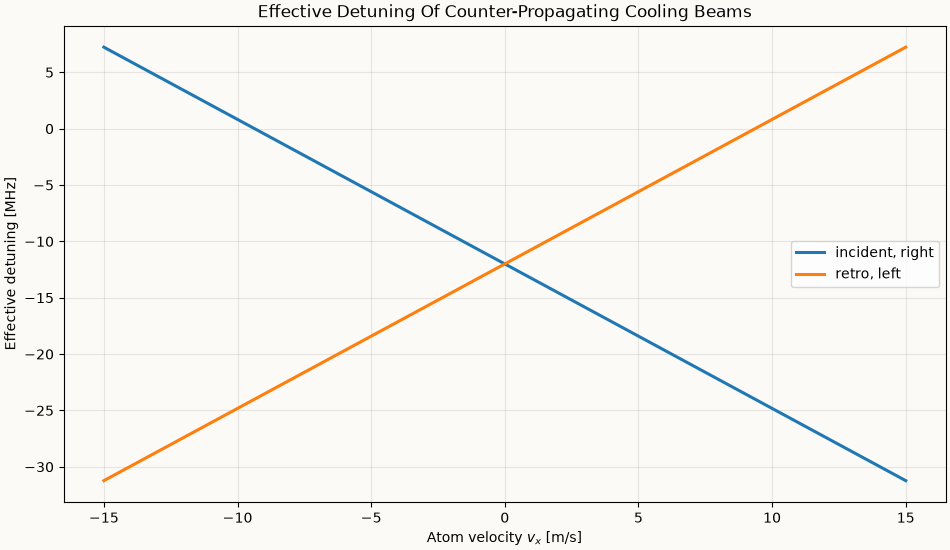

In [14]:
doppler_scan_m_per_s = list(range(-15, 16))
x_cooling_beams = [beam for beam in MOT_BEAMS if beam.axis_name == 'horizontal_x' and beam.family == 'cooling']

figure, axis = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)
figure.patch.set_facecolor('#fbfaf6')
axis.set_facecolor('#fbfaf6')
for beam in x_cooling_beams:
    detuning_curve_mhz = [effective_detuning_hz(beam, (vx, 0.0, 0.0), active_transition='cooling') / 1e6 for vx in doppler_scan_m_per_s]
    axis.plot(
        doppler_scan_m_per_s,
        detuning_curve_mhz,
        linewidth=2.2,
        label=f"{beam.propagation_sense}, {beam.circular_polarization}",
    )
axis.set_title('Effective Detuning Of Counter-Propagating Cooling Beams')
axis.set_xlabel(r'Atom velocity $v_x$ [m/s]')
axis.set_ylabel('Effective detuning [MHz]')
axis.grid(True, alpha=0.28)
axis.legend(loc='best', frameon=True)
figure.savefig(PATHS['outputs_figures'] / 'cooling_doppler_detuning_scan_x.png', dpi=180)
plt.show()


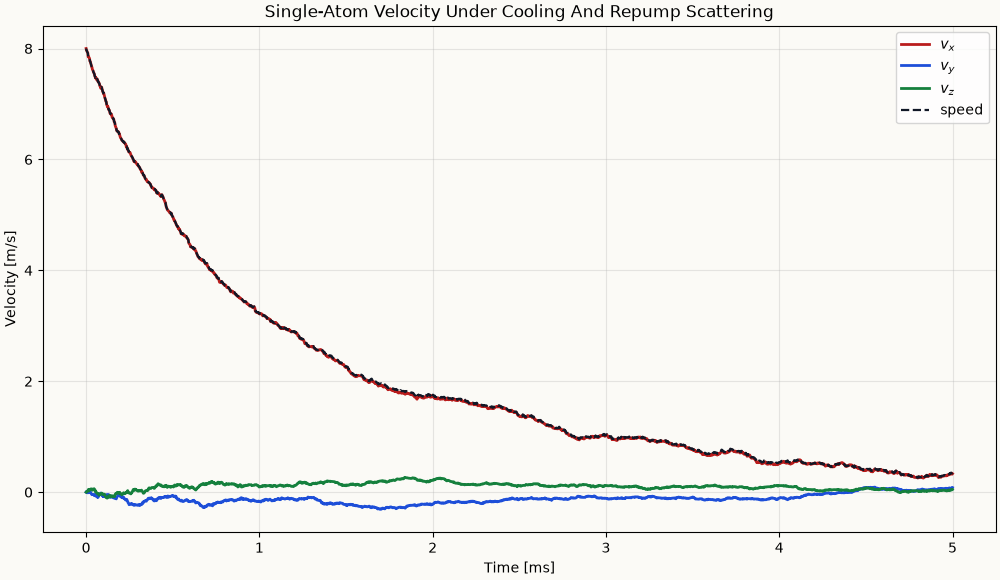

In [15]:
TRAJECTORY = simulate_scattering_trajectory(
    MOT_BEAMS,
    INITIAL_STATE,
    duration_s=SIMULATION_DURATION_S,
    time_step_s=TIME_STEP_S,
    seed=RNG_SEED,
    active_transition='cooling',
)

plot_velocity_history(
    TRAJECTORY.times_s,
    TRAJECTORY.velocities_m_per_s,
    title='Single-Atom Velocity Under Cooling And Repump Scattering',
    path=PATHS['outputs_trajectories'] / 'single_atom_velocity_history.png',
);


In [16]:
trajectory_table = pd.DataFrame({
    'time_ms': [1e3 * value for value in TRAJECTORY.times_s],
    'x_mm': [1e3 * value[0] for value in TRAJECTORY.positions_m],
    'y_mm': [1e3 * value[1] for value in TRAJECTORY.positions_m],
    'z_mm': [1e3 * value[2] for value in TRAJECTORY.positions_m],
    'vx_m_per_s': [value[0] for value in TRAJECTORY.velocities_m_per_s],
    'vy_m_per_s': [value[1] for value in TRAJECTORY.velocities_m_per_s],
    'vz_m_per_s': [value[2] for value in TRAJECTORY.velocities_m_per_s],
    'cooling_scattering_rate_per_s': TRAJECTORY.cooling_scattering_rates_per_s,
    'repump_scattering_rate_per_s': TRAJECTORY.repump_scattering_rates_per_s,
    'total_scattering_rate_per_s': TRAJECTORY.total_scattering_rates_per_s,
})
trajectory_table.head(12)


,time_ms,x_mm,y_mm,z_mm,vx_m_per_s,vy_m_per_s,vz_m_per_s,cooling_scattering_rate_per_s,repump_scattering_rate_per_s,total_scattering_rate_per_s
0,0.000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,3.118556e+06,1.835130,3.118558e+06
1,0.002,0.015936,0.000026,0.000014,7.967894,0.013061,0.006955,3.110218e+06,1.835115,3.110220e+06
2,0.004,0.031860,0.000057,0.000035,7.962008,0.015446,0.010453,3.108639e+06,1.835069,3.108641e+06
3,0.006,0.047744,0.000054,0.000051,7.942229,-0.001316,0.008102,3.103366e+06,1.834992,3.103368e+06
4,0.008,0.063604,0.000052,0.000083,7.929625,-0.001378,0.016144,3.099937e+06,1.834885,3.099938e+06
5,0.010,0.079440,0.000026,0.000119,7.918482,-0.012677,0.017809,3.096853e+06,1.834747,3.096854e+06
6,0.012,0.095143,0.000017,0.000203,7.851451,-0.004447,0.042225,3.078638e+06,1.834581,3.078640e+06
7,0.014,0.110851,0.000037,0.000268,7.853697,0.009645,0.032314,3.079063e+06,1.834385,3.079065e+06
8,0.016,0.126538,0.000023,0.000372,7.843721,-0.007069,0.051941,3.076155e+06,1.834159,3.076156e+06
9,0.018,0.142197,0.000048,0.000455,7.829559,0.012616,0.041631,3.072025e+06,1.833904,3.072027e+06


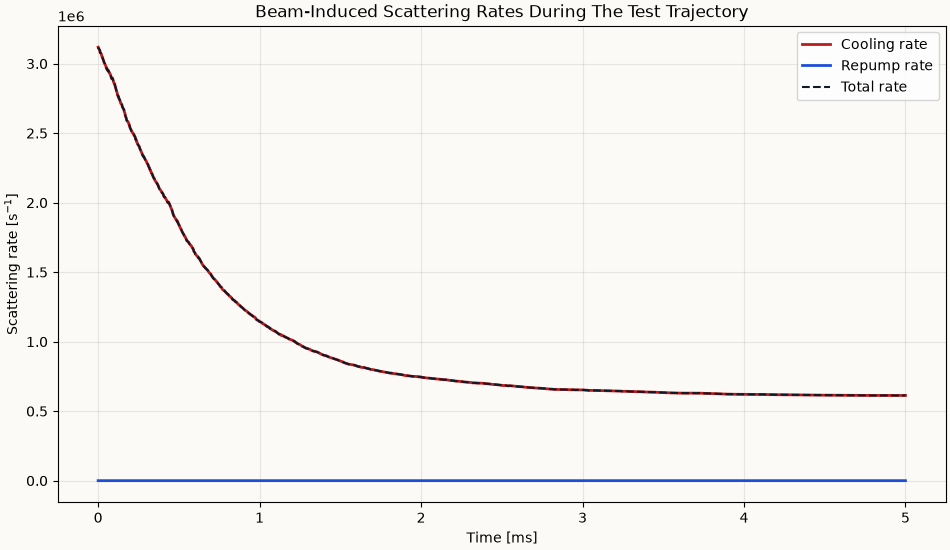

In [17]:
figure, axis = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)
figure.patch.set_facecolor('#fbfaf6')
axis.set_facecolor('#fbfaf6')
axis.plot(trajectory_table['time_ms'], trajectory_table['cooling_scattering_rate_per_s'], color='#b91c1c', linewidth=2.0, label='Cooling rate')
axis.plot(trajectory_table['time_ms'], trajectory_table['repump_scattering_rate_per_s'], color='#1d4ed8', linewidth=2.0, label='Repump rate')
axis.plot(trajectory_table['time_ms'], trajectory_table['total_scattering_rate_per_s'], color='#111827', linewidth=1.5, linestyle='--', label='Total rate')
axis.set_title('Beam-Induced Scattering Rates During The Test Trajectory')
axis.set_xlabel('Time [ms]')
axis.set_ylabel(r'Scattering rate [s$^{-1}$]')
axis.grid(True, alpha=0.28)
axis.legend(loc='best', frameon=True)
figure.savefig(PATHS['outputs_trajectories'] / 'single_atom_scattering_rates.png', dpi=180)
plt.show()


## Recoil Direction Summary

The plot below bins all recorded recoil directions onto a spherical reference grid. Red vectors summarize absorption kicks, and blue vectors summarize spontaneous-emission kicks. The arrow length is proportional to the number of scattering events assigned to that direction bin during the test trajectory.

absorption_events        4836
emission_events          4836
absorption_bins_shown       6
emission_bins_shown       116
dtype: int64

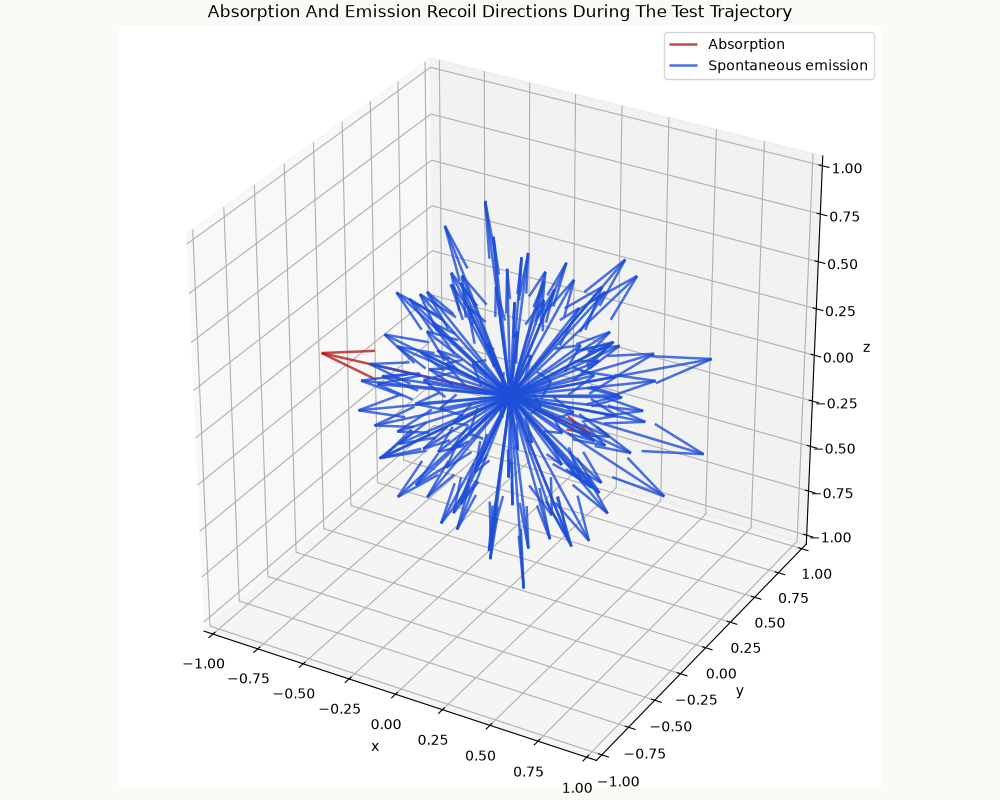

In [18]:
def fibonacci_sphere_directions(sample_count: int) -> np.ndarray:
    indices = np.arange(sample_count, dtype=float) + 0.5
    phi = np.arccos(1.0 - 2.0 * indices / sample_count)
    theta = np.pi * (1.0 + np.sqrt(5.0)) * indices
    return np.column_stack((
        np.cos(theta) * np.sin(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(phi),
    ))


def aggregate_direction_vectors(directions, reference_directions, min_count: int = 1) -> list[tuple[float, float, float]]:
    if not directions:
        return []
    direction_array = np.array(directions, dtype=float)
    counts = np.zeros(len(reference_directions), dtype=int)
    for direction in direction_array:
        best_index = int(np.argmax(reference_directions @ direction))
        counts[best_index] += 1
    max_count = counts.max()
    if max_count == 0:
        return []
    scaled_vectors = []
    for index, count in enumerate(counts):
        if count < min_count:
            continue
        scaled_vectors.append(tuple(reference_directions[index] * (count / max_count)))
    return scaled_vectors


REFERENCE_DIRECTIONS = fibonacci_sphere_directions(sample_count=120)
ABSORPTION_VECTORS = aggregate_direction_vectors(
    TRAJECTORY.absorption_kick_directions,
    REFERENCE_DIRECTIONS,
    min_count=max(1, len(TRAJECTORY.absorption_kick_directions) // 300),
)
EMISSION_VECTORS = aggregate_direction_vectors(
    TRAJECTORY.emission_kick_directions,
    REFERENCE_DIRECTIONS,
    min_count=max(2, len(TRAJECTORY.emission_kick_directions) // 180),
)

plot_recoil_direction_vectors(
    ABSORPTION_VECTORS,
    EMISSION_VECTORS,
    title='Absorption And Emission Recoil Directions During The Test Trajectory',
    path=PATHS['outputs_trajectories'] / 'single_atom_recoil_direction_vectors.png',
);

pd.Series({
    'absorption_events': len(TRAJECTORY.absorption_kick_directions),
    'emission_events': len(TRAJECTORY.emission_kick_directions),
    'absorption_bins_shown': len(ABSORPTION_VECTORS),
    'emission_bins_shown': len(EMISSION_VECTORS),
})


## Six-Direction Cooling Comparison

The grid below repeats the single-atom scattering test for six launch directions: `+x`, `-x`, `+y`, `-y`, `+z`, and `-z`. Each row uses the same initial speed magnitude and shows the full velocity history, cooling/repump scattering rates, and the signed 1D position along the launched axis.

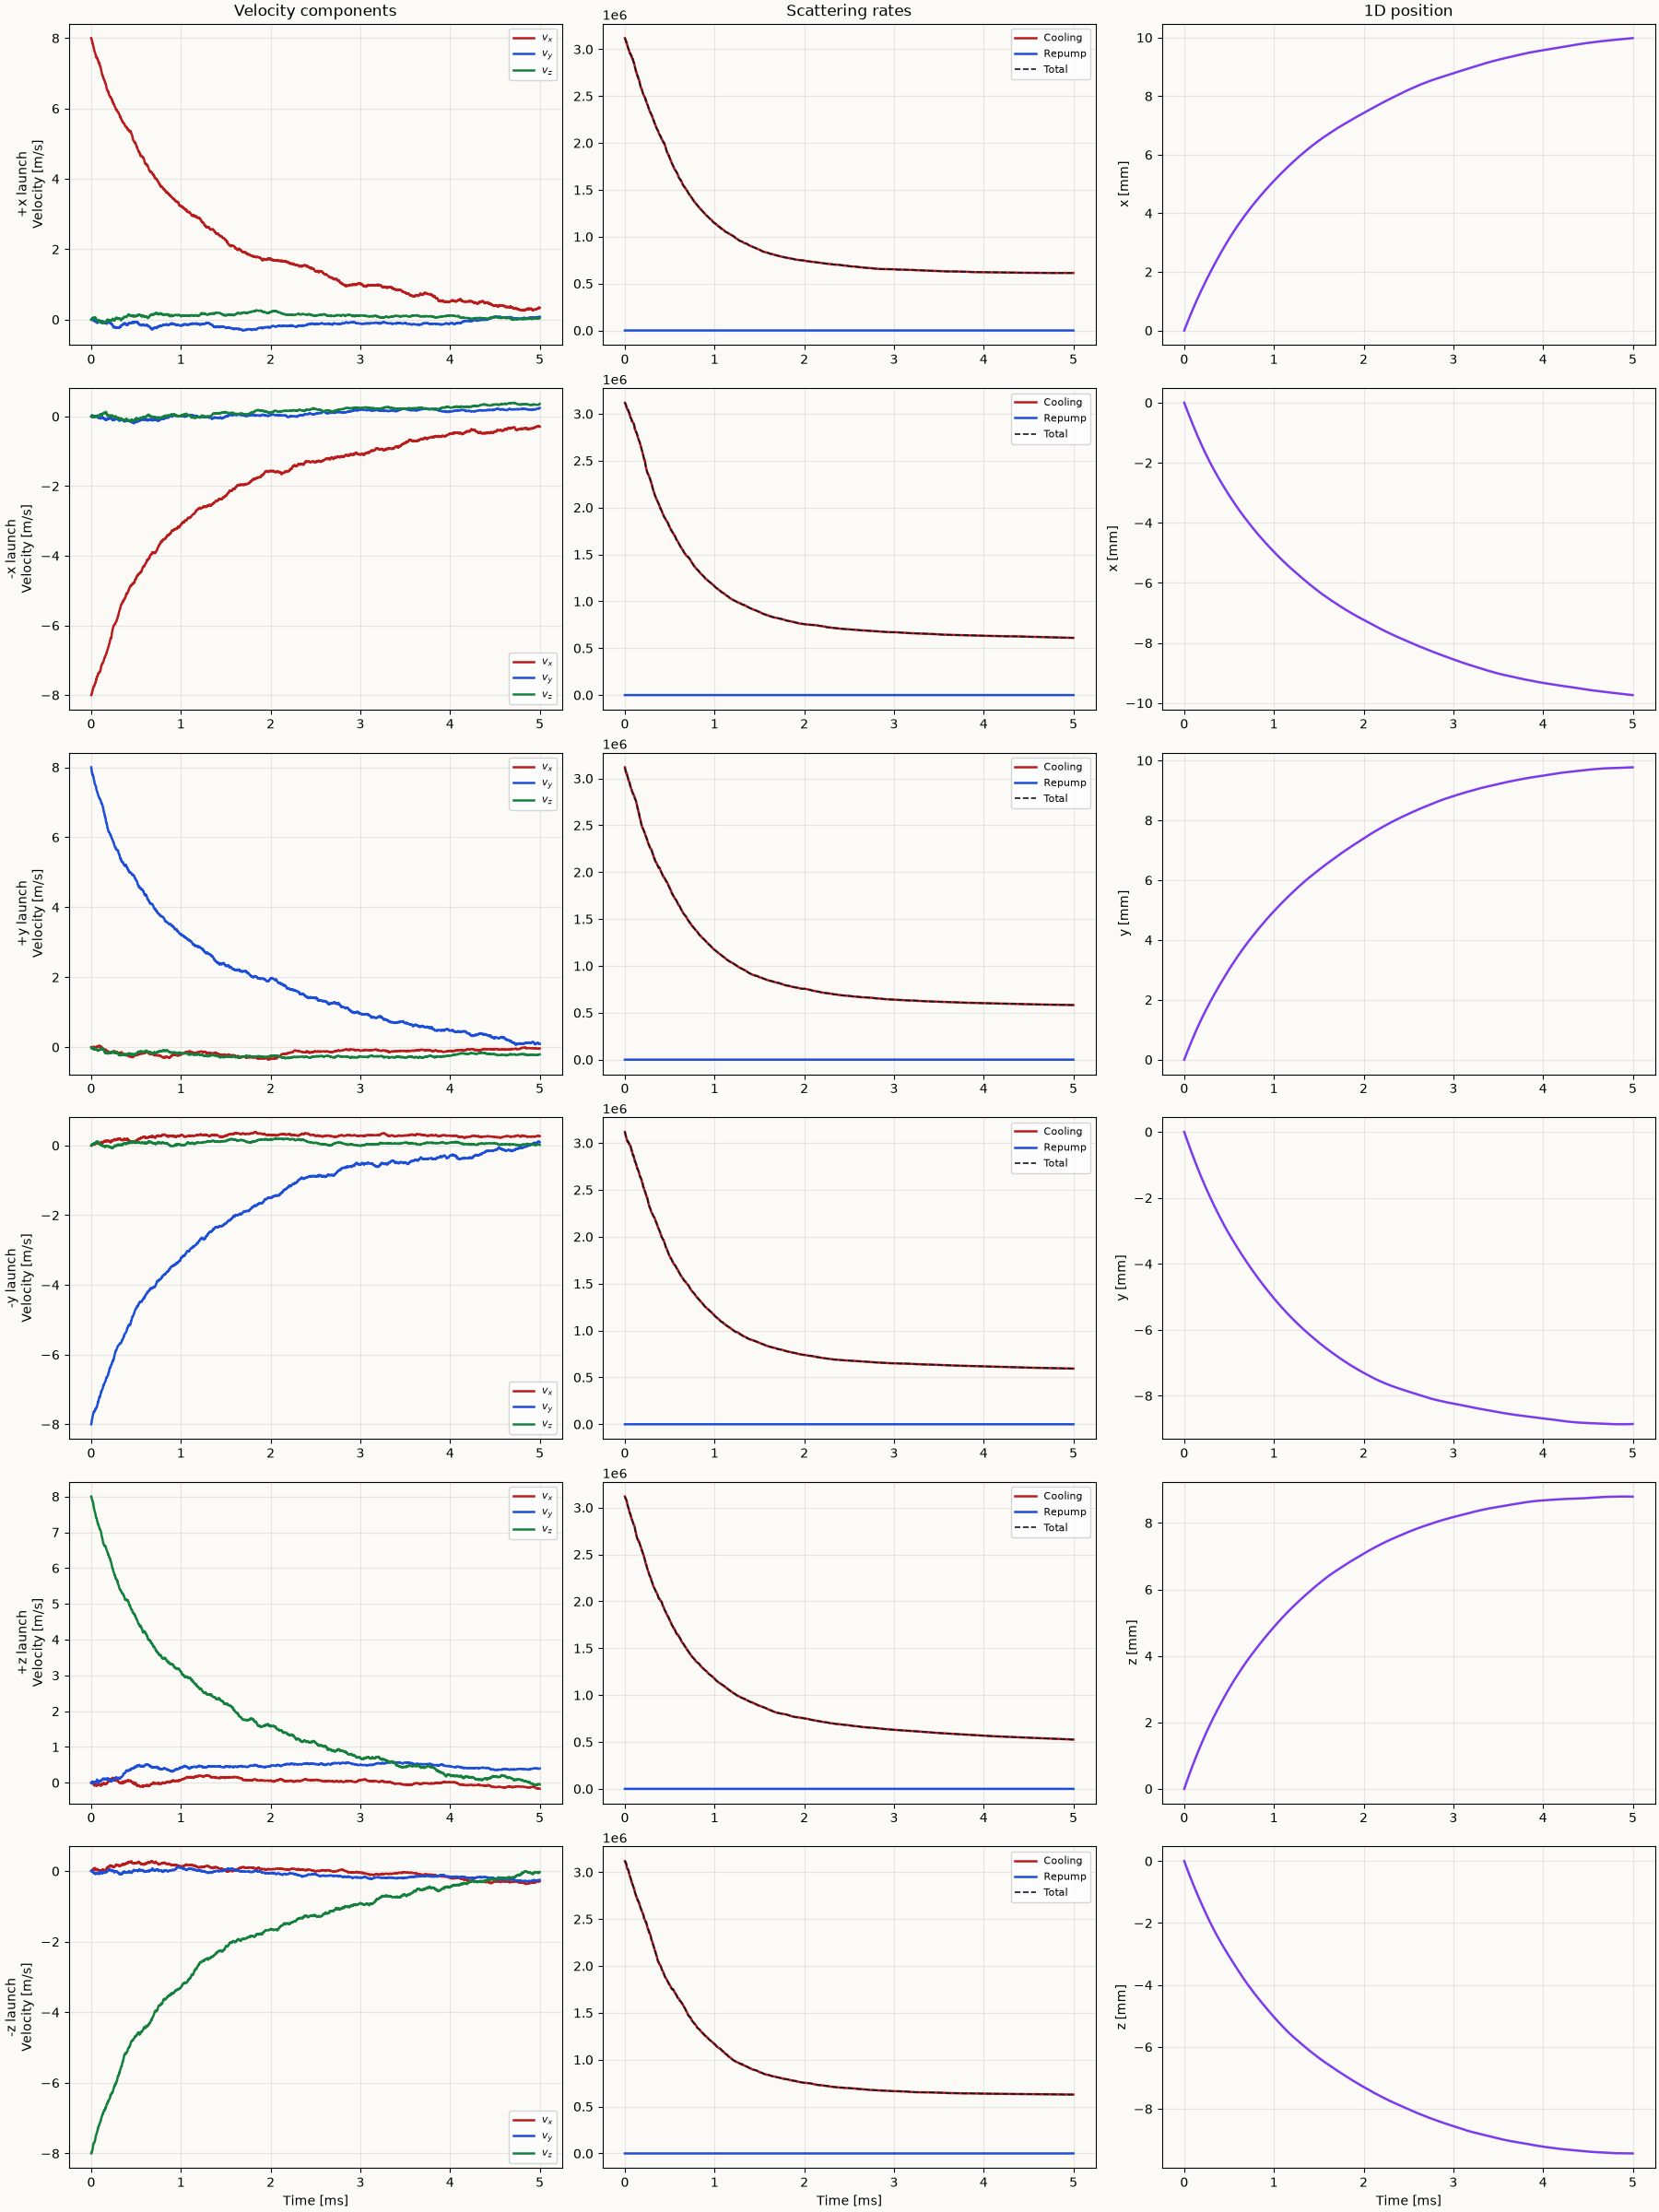

In [19]:
LAUNCH_CASES = [
    ('+x', (8.0, 0.0, 0.0), 0),
    ('-x', (-8.0, 0.0, 0.0), 0),
    ('+y', (0.0, 8.0, 0.0), 1),
    ('-y', (0.0, -8.0, 0.0), 1),
    ('+z', (0.0, 0.0, 8.0), 2),
    ('-z', (0.0, 0.0, -8.0), 2),
]

comparison_results = []
for case_index, (label, velocity_vector, axis_index) in enumerate(LAUNCH_CASES):
    case_state = AtomState(position_m=(0.0, 0.0, 0.0), velocity_m_per_s=velocity_vector)
    case_trajectory = simulate_scattering_trajectory(
        MOT_BEAMS,
        case_state,
        duration_s=SIMULATION_DURATION_S,
        time_step_s=TIME_STEP_S,
        seed=RNG_SEED + case_index,
        active_transition='cooling',
    )
    comparison_results.append({
        'label': label,
        'axis_index': axis_index,
        'trajectory': case_trajectory,
    })

figure, axes = plt.subplots(6, 3, figsize=(18, 24), constrained_layout=True)
figure.patch.set_facecolor('#fbfaf6')
column_titles = ['Velocity components', 'Scattering rates', '1D position']
for column_index, title in enumerate(column_titles):
    axes[0, column_index].set_title(title, fontsize=12)

component_colors = ['#b91c1c', '#1d4ed8', '#15803d']
component_labels = [r'$v_x$', r'$v_y$', r'$v_z$']
axis_coordinate_labels = ['x', 'y', 'z']

for row_index, result in enumerate(comparison_results):
    trajectory = result['trajectory']
    axis_index = result['axis_index']
    signed_coordinate = [1e3 * position[axis_index] for position in trajectory.positions_m]
    times_ms = [1e3 * value for value in trajectory.times_s]
    velocity_array = np.array(trajectory.velocities_m_per_s)

    velocity_axis = axes[row_index, 0]
    velocity_axis.set_facecolor('#fbfaf6')
    for component_index in range(3):
        velocity_axis.plot(
            times_ms,
            velocity_array[:, component_index],
            color=component_colors[component_index],
            linewidth=1.8,
            label=component_labels[component_index],
        )
    velocity_axis.grid(True, alpha=0.28)
    velocity_axis.set_ylabel(f"{result['label']} launch\nVelocity [m/s]")
    if row_index == len(comparison_results) - 1:
        velocity_axis.set_xlabel('Time [ms]')
    velocity_axis.legend(loc='best', fontsize=8, frameon=True)

    rate_axis = axes[row_index, 1]
    rate_axis.set_facecolor('#fbfaf6')
    rate_axis.plot(times_ms, trajectory.cooling_scattering_rates_per_s, color='#b91c1c', linewidth=1.8, label='Cooling')
    rate_axis.plot(times_ms, trajectory.repump_scattering_rates_per_s, color='#1d4ed8', linewidth=1.8, label='Repump')
    rate_axis.plot(times_ms, trajectory.total_scattering_rates_per_s, color='#111827', linewidth=1.2, linestyle='--', label='Total')
    rate_axis.grid(True, alpha=0.28)
    if row_index == len(comparison_results) - 1:
        rate_axis.set_xlabel('Time [ms]')
    rate_axis.legend(loc='best', fontsize=8, frameon=True)

    position_axis = axes[row_index, 2]
    position_axis.set_facecolor('#fbfaf6')
    position_axis.plot(times_ms, signed_coordinate, color='#7c3aed', linewidth=1.8)
    position_axis.grid(True, alpha=0.28)
    position_axis.set_ylabel(f"{axis_coordinate_labels[axis_index]} [mm]")
    if row_index == len(comparison_results) - 1:
        position_axis.set_xlabel('Time [ms]')

figure.savefig(PATHS['outputs_trajectories'] / 'six_direction_cooling_comparison_grid.png', dpi=180)
plt.show()
